# 1. Load dataloaders


In [9]:
from data.dataloader import create_tremor_dataloaders

train_loader, val_loader = create_tremor_dataloaders(
    csv_path="../project_datasets/tremor/tremor_features.csv",
    batch_size=32,
    print_details=True,
    split_by_subject=False
)


Sample-Level Random Split
Train samples: 4828 | Val samples: 1207


Sample counts:
Train samples: 4828 | Val samples: 1207

Train Class Distribution:
  Healthy     : 1074 (22.2%)
  Parkinson   : 3754 (77.8%)



# 2. Create models


In [10]:
from Models.model_V12 import TremorClassifier

model = TremorClassifier()
model_name = "Tremor_Model_final"

# 3. Train models


In [ ]:
from training.trainer import train

train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,

    model_name=model_name,
    run_name=model_name,

    load_pretrained="checkpoints/Tremor_Model_trained_BEST.pth",
    checkpoint_dir="checkpoints/",

    max_lr=5e-5,
    epochs=100,

    per_movement=False,
    debug_mode=False)

In [ ]:
# !tensorboard --logdir=runs

In [11]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load model
checkpoint = torch.load(
    "checkpoints/Tremor_Model_final.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Loaded pretrained model:")
print(f"- val_loss={checkpoint['val_loss']:.4f}")
print(f"- balanced_accuracy={checkpoint['balanced_accuracy']:.4f}")
print(f"- macro_f1={checkpoint['macro_f1']:.4f}")

Loaded pretrained model:
- val_loss=0.3560
- balanced_accuracy=0.9220
- macro_f1=0.8930


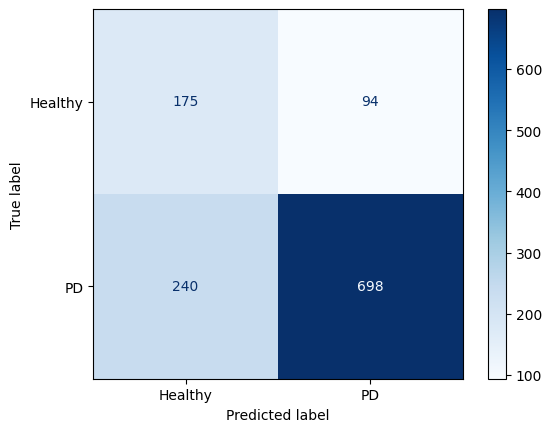

In [12]:
from training.confusion_mat import plot_confusion_matrix

plot_confusion_matrix(
    model=model,
    dataloader=val_loader,
    device="cuda",
    class_names=["Healthy", "PD"],
    threshold=0.5,
)